Valeurs Manquantes

In [1]:
import pandas as pd

def afficher_valeurs_manquantes(df):
    """
    Calcule et retourne le nombre de valeurs manquantes par caractéristique.
    Ne conserve que les colonnes ayant au moins une donnée manquante, triées par ordre décroissant.
    """
    # 1. df.isna() crée un masque booléen, puis .sum() compte les True (donc les valeurs manquantes) par colonne
    manquants = df.isna().sum()
    
    # 2. Filtre pour exclure les colonnes qui ont 0 valeur manquante
    manquants_filtres = manquants[manquants > 0]
    
    # 3. Trie du plus grand nombre de valeurs manquantes au plus petit pour cibler les pires cas
    manquants_tries = manquants_filtres.sort_values(ascending=False)
    
    return manquants_tries

url = "https://archive.ics.uci.edu/ml/machine-learning-databases/00383/risk_factors_cervical_cancer.csv"
df = pd.read_csv(url, na_values=["?"])
valeurs_nulles = afficher_valeurs_manquantes(df)
print(valeurs_nulles)

STDs: Time since first diagnosis      787
STDs: Time since last diagnosis       787
IUD (years)                           117
IUD                                   117
Hormonal Contraceptives               108
Hormonal Contraceptives (years)       108
STDs (number)                         105
STDs                                  105
STDs:vulvo-perineal condylomatosis    105
STDs:vaginal condylomatosis           105
STDs:pelvic inflammatory disease      105
STDs:syphilis                         105
STDs:genital herpes                   105
STDs:molluscum contagiosum            105
STDs:HIV                              105
STDs:AIDS                             105
STDs:condylomatosis                   105
STDs:cervical condylomatosis          105
STDs:HPV                              105
STDs:Hepatitis B                      105
Num of pregnancies                     56
Number of sexual partners              26
Smokes (packs/year)                    13
Smokes (years)                    

Valeurs aberrantes

In [2]:
import pandas as pd
import numpy as np

def afficher_valeurs_aberrantes(df):
    """
    Détecte et compte le nombre de valeurs aberrantes pour chaque colonne numérique
    en utilisant la méthode de l'écart interquartile (IQR).
    """
    # 1. On ne garde que les colonnes numériques (ignorer les dates, textes, etc.)
    df_num = df.select_dtypes(include=[np.number])
    
    valeurs_aberrantes = {}
    
    # 2. On boucle sur chaque colonne numérique
    for col in df_num.columns:
        # Calcul du 1er quartile (25%) et du 3ème quartile (75%)
        Q1 = df_num[col].quantile(0.25)
        Q3 = df_num[col].quantile(0.75)
        
        # Calcul de l'IQR
        IQR = Q3 - Q1
        
        # Définition des seuils
        seuil_inferieur = Q1 - 1.5 * IQR
        seuil_superieur = Q3 + 1.5 * IQR
        
        # Comptage des valeurs qui dépassent ces seuils
        nb_outliers = ((df_num[col] < seuil_inferieur) | (df_num[col] > seuil_superieur)).sum()
        
        # On ne stocke que les colonnes qui ont au moins une valeur aberrante
        if nb_outliers > 0:
            valeurs_aberrantes[col] = nb_outliers
            
    # 3. On retourne une Série Pandas triée par ordre décroissant
    return pd.Series(valeurs_aberrantes).sort_values(ascending=False)

url = "https://archive.ics.uci.edu/ml/machine-learning-databases/00383/risk_factors_cervical_cancer.csv"
df = pd.read_csv(url, na_values=["?"])
outliers = afficher_valeurs_aberrantes(df)
print("Valeurs aberrantes par colonne :\n", outliers)

Valeurs aberrantes par colonne :
 Smokes                                123
Smokes (packs/year)                   123
Smokes (years)                        123
IUD (years)                            83
IUD                                    83
STDs (number)                          79
STDs                                   79
Schiller                               74
STDs: Number of diagnosis              71
Hormonal Contraceptives (years)        68
Number of sexual partners              68
Biopsy                                 55
Citology                               44
STDs:condylomatosis                    44
STDs:vulvo-perineal condylomatosis     43
First sexual intercourse               41
Hinselmann                             35
Dx                                     24
Dx:HPV                                 18
Dx:Cancer                              18
STDs:syphilis                          18
STDs:HIV                               18
Num of pregnancies                     10


Déséquilibre de la base de données

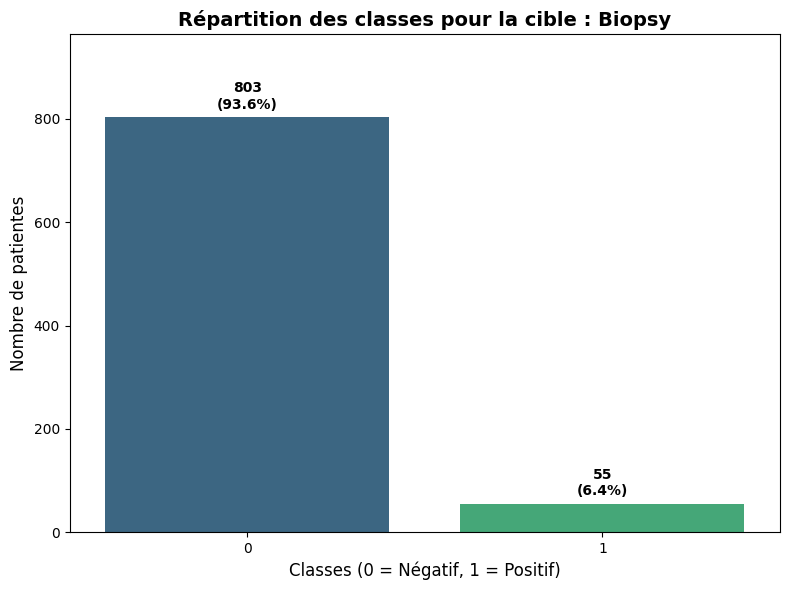

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

def afficher_desequilibre_classes(df, nom_colonne_cible):
    """
    Affiche un diagramme à barres pour visualiser le déséquilibre des classes
    dans la variable cible avec les pourcentages exacts.
    """
    plt.figure(figsize=(8, 6))
    
    # Création du graphique avec Seaborn
    ax = sns.countplot(data=df, x=nom_colonne_cible, hue=nom_colonne_cible, palette="viridis", legend=False)
    
    # Calcul du total pour les pourcentages
    total = len(df[nom_colonne_cible].dropna())
    
    # Ajout des annotations (nombre exact et pourcentage) sur chaque barre
    for p in ax.patches:
        hauteur = p.get_height()
        if hauteur > 0:
            pourcentage = f'{100 * hauteur / total:.1f}%'
            # CORRECTION : on utilise 'ha' au lieu de 'ha_alignment'
            ax.annotate(f'{int(hauteur)}\n({pourcentage})', 
                        (p.get_x() + p.get_width() / 2., hauteur),
                        ha='center', va='center', 
                        xytext=(0, 15), textcoords='offset points',
                        fontweight='bold')
    
    plt.title(f"Répartition des classes pour la cible : {nom_colonne_cible}", fontsize=14, fontweight='bold')
    plt.xlabel("Classes (0 = Négatif, 1 = Positif)", fontsize=12)
    plt.ylabel("Nombre de patientes", fontsize=12)
    
    # Augmenter un peu la limite haute de l'axe Y pour laisser de la place au texte
    plt.ylim(0, df[nom_colonne_cible].value_counts().max() * 1.2)
    
    plt.tight_layout()
    plt.show()

url = "https://archive.ics.uci.edu/ml/machine-learning-databases/00383/risk_factors_cervical_cancer.csv"
df = pd.read_csv(url, na_values=["?"])
afficher_desequilibre_classes(df, 'Biopsy')